# MRR Analysis — Tidemill API vs Stripe

Compare Monthly Recurring Revenue computed by the subscriptions engine with raw Stripe data.

**API base:** `https://tidemill.xyz`  
**Stripe mode:** Test (sandbox)

In [ ]:
import os
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import requests
import stripe

warnings.filterwarnings("ignore", "Unverified HTTPS")

API = os.environ.get("TIDEMILL_API", "https://tidemill.xyz")
stripe.api_key = os.environ["STRIPE_API_KEY"]

START, END = "2025-09-01", "2026-03-31"

plt.rcParams.update({"figure.figsize": (12, 5), "axes.grid": True, "grid.alpha": 0.3})


def api_get(path, **params):
    r = requests.get(f"{API}{path}", params=params, verify=False)
    r.raise_for_status()
    return r.json()

## 1. Current MRR & ARR from Tidemill API

In [2]:
mrr_current = int(api_get("/api/metrics/mrr", at="2026-03-01"))
arr_current = int(api_get("/api/metrics/arr", at="2026-03-01"))

print(f"MRR (Tidemill):  ${mrr_current / 100:,.2f}")
print(f"ARR (Tidemill):  ${arr_current / 100:,.2f}")
print(f"ARR check:       ${mrr_current * 12 / 100:,.2f}  (MRR x 12)")

MRR (Tidemill):  $589.45
ARR (Tidemill):  $7,073.40
ARR check:       $7,073.40  (MRR x 12)


## 2. MRR from Stripe (ground truth)

Compute MRR directly from active Stripe subscriptions across all test clocks for comparison.

In [3]:
def stripe_mrr_for_sub(sub):
    """Compute monthly MRR in cents from a Stripe subscription."""
    total = 0
    for item in sub["items"]["data"]:
        price = item["price"]
        qty = item.get("quantity", 1) or 1
        unit_amount = price.get("unit_amount", 0) or 0
        amount = unit_amount * qty
        rec = price.get("recurring") or {}
        interval = rec.get("interval", "month")
        interval_count = rec.get("interval_count", 1) or 1
        if interval == "month":
            total += amount // interval_count
        elif interval == "year":
            total += amount // (12 * interval_count)
        elif interval == "week":
            total += int(amount * 52 / (12 * interval_count))
    return total


# Collect all subscriptions across test clocks
clock_ids = [c.id for c in stripe.test_helpers.TestClock.list(limit=100).auto_paging_iter()]
stripe_subs = []
for cid in clock_ids:
    for sub in stripe.Subscription.list(
        limit=100, test_clock=cid, status="all"
    ).auto_paging_iter():
        stripe_subs.append(dict(sub))

df_stripe = pd.DataFrame(
    [
        {
            "id": s["id"],
            "customer": s["customer"],
            "status": s["status"],
            "mrr_cents": stripe_mrr_for_sub(s),
            "currency": s.get("currency", "usd"),
        }
        for s in stripe_subs
    ]
)

print(f"Stripe subscriptions: {len(df_stripe)}")
print(f"  Active:   {(df_stripe.status == 'active').sum()}")
print(f"  Canceled: {(df_stripe.status == 'canceled').sum()}")
print(f"  Trialing: {(df_stripe.status == 'trialing').sum()}")
print()

stripe_mrr = df_stripe[df_stripe.status == "active"].mrr_cents.sum()
print(f"MRR (Stripe):    ${stripe_mrr / 100:,.2f}")
print(f"MRR (Tidemill):  ${mrr_current / 100:,.2f}")
diff = mrr_current - stripe_mrr
print(f"Difference:      ${diff / 100:,.2f}  ({'match!' if diff == 0 else 'see breakdown below'})")

Stripe subscriptions: 15
  Active:   12
  Canceled: 3
  Trialing: 0

MRR (Stripe):    $589.45
MRR (Tidemill):  $589.45
Difference:      $0.00  (match!)


## 3. Per-subscription MRR comparison

In [4]:
# Side-by-side: Stripe MRR per subscription vs what Tidemill recorded
df_compare = df_stripe[["id", "status", "mrr_cents"]].rename(
    columns={"mrr_cents": "stripe_mrr_cents"}
)
df_compare["stripe_mrr"] = df_compare.stripe_mrr_cents.apply(lambda c: f"${c / 100:,.2f}")
df_compare = df_compare.sort_values("stripe_mrr_cents", ascending=False).reset_index(drop=True)
df_compare

,id,status,stripe_mrr_cents,stripe_mrr
0,sub_1TIOY7CMLOTbZAd7Syq68M0D,active,20750,$207.50
1,sub_1TIOYMCMLOTbZAd7eIDRjogs,active,7900,$79.00
2,sub_1TIOYJCMLOTbZAd7PHo4bTCa,active,7900,$79.00
3,sub_1TIOYECMLOTbZAd7WsM4EszF,canceled,7900,$79.00
4,sub_1TIOXyCMLOTbZAd7qJ2eeOvD,active,7900,$79.00
5,sub_1TIOXtCMLOTbZAd772tj1s2e,active,7900,$79.00
6,sub_1TIOY2CMLOTbZAd7au6WJFlZ,active,6583,$65.83
7,sub_1TIOYYCMLOTbZAd7NQotGchs,canceled,2,$0.02
8,sub_1TIOYVCMLOTbZAd71NBtdfB7,active,2,$0.02
9,sub_1TIOYTCMLOTbZAd7sumq2tVH,active,2,$0.02


## 4. MRR Breakdown (movements)

In [ ]:
breakdown = api_get("/api/metrics/mrr/breakdown", start=START, end=END)
df_bd = pd.DataFrame(breakdown)
df_bd["amount"] = df_bd["amount_base"].astype(int) / 100

colors = {"new": "#2ecc71", "expansion": "#3498db", "contraction": "#e67e22", "churn": "#e74c3c"}

fig, ax = plt.subplots()
bars = ax.bar(
    df_bd.movement_type,
    df_bd.amount,
    color=[colors.get(t, "#95a5a6") for t in df_bd.movement_type],
)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("MRR Movements (Sep 2025 - Mar 2026)")
ax.set_ylabel("Amount ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

for bar, val in zip(bars, df_bd.amount, strict=True):
    y = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y + (5 if y >= 0 else -15),
        f"${val:,.0f}",
        ha="center",
        fontweight="bold",
        fontsize=11,
    )

plt.tight_layout()
plt.show()

print("\nNet MRR change:", f"${df_bd.amount.sum():,.2f}")

## 5. MRR by subscription status (Stripe vs Tidemill)

Connected sources: ['Stripe']



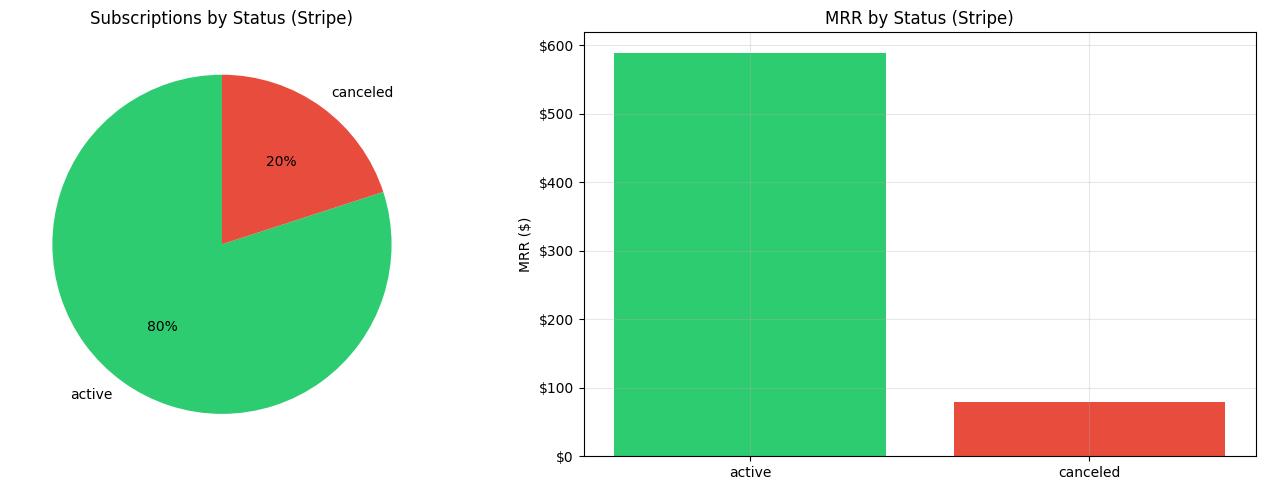

,status,count,mrr_cents,mrr
0,active,12,58945,$589.45
1,canceled,3,7904,$79.04


In [6]:
# Tidemill sources view
sources = api_get("/api/sources")
print("Connected sources:", [s["name"] for s in sources])
print()

# Stripe subscription status breakdown with MRR
status_summary = (
    df_stripe.groupby("status")
    .agg(
        count=("id", "count"),
        mrr_cents=("mrr_cents", "sum"),
    )
    .reset_index()
)
status_summary["mrr"] = status_summary.mrr_cents.apply(lambda c: f"${c / 100:,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie: subscription count by status
status_colors = {
    "active": "#2ecc71",
    "canceled": "#e74c3c",
    "trialing": "#f39c12",
    "past_due": "#e67e22",
}
axes[0].pie(
    status_summary["count"],
    labels=status_summary.status,
    autopct="%1.0f%%",
    colors=[status_colors.get(s, "#95a5a6") for s in status_summary.status],
    startangle=90,
)
axes[0].set_title("Subscriptions by Status (Stripe)")

# Bar: MRR by status
axes[1].bar(
    status_summary.status,
    status_summary.mrr_cents / 100,
    color=[status_colors.get(s, "#95a5a6") for s in status_summary.status],
)
axes[1].set_title("MRR by Status (Stripe)")
axes[1].set_ylabel("MRR ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.show()

status_summary